## Gregor's Space: Ridge Regression and LASSO

### Setup: Import libraries, read and split dataset

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report

In [37]:
import pandas as pd
data_final = pd.read_csv("../data/data_final_kingcounty_houses.csv")

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 1: Split BEFORE scaling

X = data_final.drop('price', axis=1)
y = data_final['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Initialize the Scaler (Z-Transform)

scaler = StandardScaler()

# Step 3: Fit and Transform the TRAIN set

X_train_scaled = scaler.fit_transform(X_train)

# Step 4: ONLY Transform the TEST set

X_test_scaled = scaler.transform(X_test)

In [40]:
from sklearn.linear_model import LinearRegression

linreg_model = LinearRegression()
linreg_model.fit(X_train_scaled, y_train)
ypred_test_linreg = linreg_model.predict(X_test_scaled)
ypred_train_linreg = linreg_model.predict(X_train_scaled)

### Ridge Regression

In [41]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-4, 4, 100)

ridge = RidgeCV(alphas=alphas, cv=5, scoring="neg_mean_absolute_error")
ridge.fit(X_train_scaled, y_train)

ypred_test_ridge = ridge.predict(X_test_scaled)
ypred_train_ridge = ridge.predict(X_train_scaled)

print("Best alpha:", ridge.alpha_)

Best alpha: 2718.5882427329457


### LASSO Regression

In [42]:
# Lasso Regression with Cross Validation:
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV

lasso = LassoCV(alphas=None, cv=5, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

ypred_test_lasso = lasso.predict(X_test_scaled)
ypred_train_lasso = lasso.predict(X_train_scaled)

print("Best alpha:", lasso.alpha_)

c:\Users\gkahl\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1641: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


Best alpha: 413.3572031827747


### Elastic Net Regression

In [48]:
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import ElasticNetCV

elastic = ElasticNetCV(
    alphas=[0.01, 0.1, 1, 10],
    l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1],
    cv=5,
    random_state=42,
    max_iter=10000
)
elastic.fit(X_train_scaled, y_train)

print("Best alpha:", elastic.alpha_)
print("Best l1_ratio:", elastic.l1_ratio_)

ypred_test_elastic = elastic.predict(X_test_scaled)
ypred_train_elastic = elastic.predict(X_train_scaled)

Best alpha: 0.1
Best l1_ratio: 0.95


In [45]:
from sklearn.linear_model import ElasticNetCV

elastic_cv = ElasticNetCV(
    alphas=[0.01, 0.1, 1, 10],
    l1_ratio=[0.1, 0.5, 0.9],
    cv=5,
    random_state=42
)

elastic_cv.fit(X_train, y_train)

ypred_test_elastic = elastic_cv.predict(X_test)
ypred_train_elastic = elastic_cv.predict(X_train)

In [50]:
# Dataframe with rows Linear Regression, Ridge Regression, LASSO Regression, Elastic Net Regression
# columns: MAE_train, MAE_test, RMSE_train, RMSE_test, R2_train, R2_test

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_train, ypred_train, y_test, ypred_test):
    return {
        "MAE_train": mean_absolute_error(y_train, ypred_train),
        "MAE_test": mean_absolute_error(y_test, ypred_test),
        
        "RMSE_train": np.sqrt(mean_squared_error(y_train, ypred_train)),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, ypred_test)),
        
        "R²_train": r2_score(y_train, ypred_train),
        "R²_test": r2_score(y_test, ypred_test),
    }

results = pd.DataFrame({
    "Linear Regression": evaluate(y_train, ypred_train_linreg, y_test, ypred_test_linreg),
    "Ridge Regression": evaluate(y_train, ypred_train_ridge, y_test, ypred_test_ridge),
    "Lasso Regression": evaluate(y_train, ypred_train_lasso, y_test, ypred_test_lasso),
    "Elastic Net": evaluate(y_train, ypred_train_elastic, y_test, ypred_test_elastic)
}).T

results

,MAE_train,MAE_test,RMSE_train,RMSE_test,R²_train,R²_test
Linear Regression,124965.270472,127658.698694,198915.653485,213981.920064,0.697146,0.697121
Ridge Regression,121897.999557,125065.576893,202034.752819,218239.286367,0.687574,0.684949
Lasso Regression,124756.536860,127484.426437,198930.978585,214079.728866,0.697099,0.696844
Elastic Net,124710.538594,127416.173172,198924.019434,214043.209064,0.697121,0.696947


Optimizing the hyperparameters using cross-validation has led to only slight improvements. In the case of Ridge, MAE was significantly improved (by 3000 on the training set and 2600 on the test set), but R² slightly went down at the same time.

Let's try polynomial feature engineering combined with LASSO to select the most important features:

In [51]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, max_iter=10000))
])

pipe.fit(X_train, y_train)

ypred_test_lasso = pipe.predict(X_test)
ypred_train_lasso = pipe.predict(X_train)

c:\Users\gkahl\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.368e+11, tolerance: 1.728e+11
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\gkahl\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.083e+11, tolerance: 1.795e+11
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\gkahl\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.116e+11

Combining quadratic feature Engineering and Lasso Regression yields much better results!

In [52]:
res_lasso = pd.DataFrame({
    "Lasso Regression": evaluate(y_train, ypred_train_lasso, y_test, ypred_test_lasso)
}).T

res_lasso

,MAE_train,MAE_test,RMSE_train,RMSE_test,R²_train,R²_test
Lasso Regression,105864.827036,112898.017312,164559.858033,193246.004749,0.792727,0.752978


## Presentation

In [53]:
lasso = pipe.named_steps["lasso"]
print(lasso.alpha_)
print(f"Best alpha: {lasso.alpha_:.6f}")
poly = pipe.named_steps["poly"]

feature_names = poly.get_feature_names_out(X_train.columns)
coef_lasso = lasso.coef_

273.4553734021531
Best alpha: 273.455373


In [54]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef_lasso
})

coef_df["abs_coef"] = coef_df["coef"].abs()
zero_features = coef_df[coef_df["coef"] == 0]
important_features = coef_df[coef_df["coef"] != 0].sort_values(
    by="abs_coef", ascending=False
)

In [55]:
print(important_features.head(10))
print("Total features:", len(coef_df))
print("Zero coefficients:", (coef_df["coef"] == 0).sum())
print("Selected features:", (coef_df["coef"] != 0).sum())

                     feature           coef       abs_coef
83         sqft_living grade  279946.606081  279946.606081
207  sqft_living15 house_age  123241.288458  123241.288458
60     bathrooms sqft_living  121960.301960  121960.301960
18                 house_age -116412.670291  116412.670291
89          sqft_living year -112963.881483  112963.881483
204       sqft_living15 year -102835.892499  102835.892499
157  condition sqft_living15   87257.677023   87257.677023
227              house_age^2   82303.261641   82303.261641
3                sqft_living  -77105.604788   77105.604788
189                 lat year   62467.259188   62467.259188
Total features: 230
Zero coefficients: 112
Selected features: 118


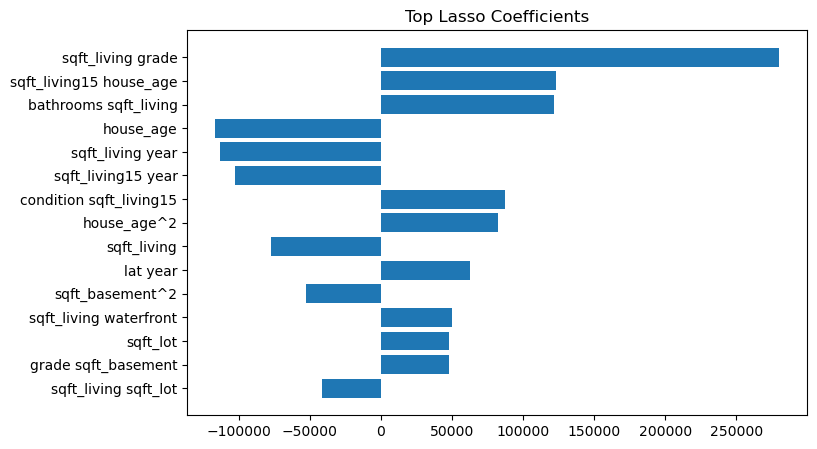

In [58]:
import matplotlib.pyplot as plt

top = important_features.head(15)

plt.figure(figsize=(8,5))
plt.barh(top["feature"], top["coef"])
plt.gca().invert_yaxis()
plt.title("Top Lasso Coefficients")
plt.show()

grouped = coef_df.groupby("base_feature")["abs_coef"].sum().sort_values(ascending=False)

In [65]:
# Final Comparison:
"""
RANDOM FOREST FINAL
--- Evaluation: No Outliers (<1.5M) [Last Dance Edition] ---
MAE: 58044.37
RMSE: 88464.32
R² Test: 0.8680
R² Train: 0.9473
"""

res_jalvaro = pd.DataFrame({
    "MAE": 58044.37, 
    "RMSE": 88464.32,
    "R² Test": 0.8680,
    "R² Train": 0.9473})

res_jalvaro

"""
final_comparison = pd.DataFrame({
    "Greg's Lasso Regression (quadratic features)": evaluate(y_train, ypred_train_lasso, y_test, ypred_test_lasso),
    "Jalvaro's Random Forest (Last Dance Edition)": evaluate(y_train, ypred_train_ridge, y_test, ypred_test_ridge),
    "Lasso Regression": evaluate(y_train, ypred_train_lasso, y_test, ypred_test_lasso),
    "Elastic Net": evaluate(y_train, ypred_train_elastic, y_test, ypred_test_elastic)
}).T

final_comparison
"""

ValueError: If using all scalar values, you must pass an index

In [67]:
res_jalvaro = pd.DataFrame([{
    "MAE": 58044.37, 
    "RMSE": 88464.32,
    "R² Test": 0.8680,
    "R² Train": 0.9473
}])
res_jalvaro

,MAE,RMSE,R² Test,R² Train
0,58044.37,88464.32,0.868,0.9473
